In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/wild_pansy.jpg
/kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/hard-leaved_pocket_orchid.jpg
/kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/cautleya_spicata.jpg
/kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/orange_dahlia.jpg
/kaggle/input/datasets/nabeelsawafta/myjson/label_map.json


In [2]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))

2026-03-13 15:25:27.223380: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773415527.465091      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773415527.534194      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773415528.060492      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773415528.060537      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773415528.060540      55 computation_placer.cc:177] computation placer alr

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!nvidia-smi

Fri Mar 13 15:25:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             27W /  250W |       3MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Install required packages
!pip install -q tensorflow
!pip install -q tensorflow_datasets
!pip install -q tqdm

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds

tfds.disable_progress_bar()

In [7]:
import logging

logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [8]:
print("Using:")
print("\t• TensorFlow version:", tf.__version__)
print("\t• Keras version:", tf.keras.__version__)

if tf.config.list_physical_devices('GPU'):
    print("\t• Running on GPU")
else:
    print("\t• GPU device not found. Running on CPU")

Using:
	• TensorFlow version: 2.19.0
	• Keras version: 3.10.0
	• Running on GPU


In [9]:
# TODO: Load the dataset with TensorFlow Datasets.
dataset, dataset_info = tfds.load('oxford_flowers102', as_supervised=True, with_info=True)

# TODO: Create the 3 data sets: Training, validation, and testing
training_set = dataset['train']
validation_set = dataset['validation']
test_set = dataset['test']


Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


I0000 00:00:1773415589.836143      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [10]:
# TODO: Get the number of examples in each set from the dataset info.
num_training_examples = dataset_info.splits['train'].num_examples
num_validation_examples = dataset_info.splits['validation'].num_examples
num_test_examples = dataset_info.splits['test'].num_examples

print("Number of training examples:", num_training_examples)
print("Number of validation examples:", num_validation_examples)
print("Number of test examples:", num_test_examples)

# TODO: Get the number of classes in the dataset from the dataset info.
num_classes = dataset_info.features['label'].num_classes
print("Number of classes:", num_classes)

Number of training examples: 1020
Number of validation examples: 1020
Number of test examples: 6149
Number of classes: 102


In [11]:
# TODO: Print the shape and corresponding label of 3 images in the training set.
for image, label in training_set.take(3):
    print("Shape:", image.shape, "| Label:", label.numpy())

Shape: (500, 667, 3) | Label: 72
Shape: (500, 666, 3) | Label: 84
Shape: (670, 500, 3) | Label: 70


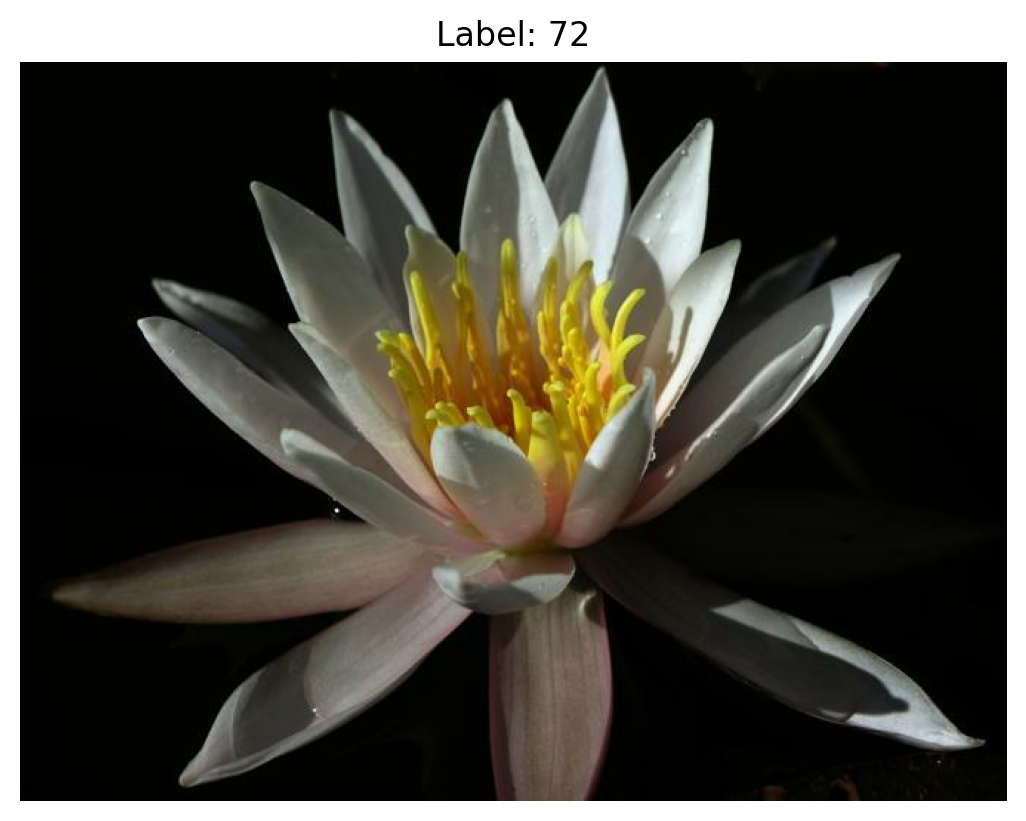

In [12]:
# TODO: Plot 1 image from the training set. Set the title
# of the plot to the corresponding image label.
for image, label in training_set.take(1):
    plt.imshow(image)
    plt.title("Label: " + str(label.numpy()))
    plt.axis('off')
    plt.show()

In [13]:
import json
with open('/kaggle/input/datasets/nabeelsawafta/myjson/label_map.json', 'r') as f:
    class_names = json.load(f)

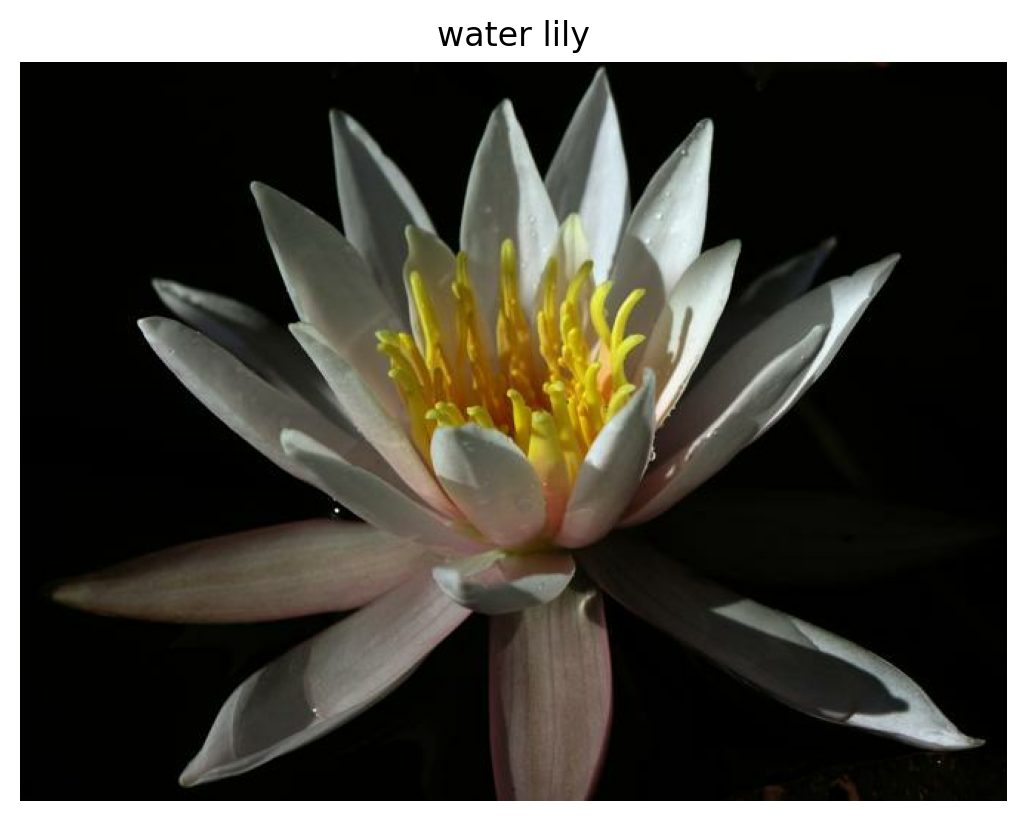

In [14]:
# TODO: Plot 1 image from the training set. Set the title
# of the plot to the corresponding class name.
for image, label in training_set.take(1):
    plt.imshow(image)
    plt.title(class_names[str(label.numpy())])
    plt.axis('off')
    plt.show()

In [15]:
def format_image(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (224, 224))
    image /= 255.0
    return image, label

batch_size = 64

# Only the training set who needs to be shuffeled 
training_batches = training_set.cache().shuffle(num_training_examples//4).map(format_image).batch(batch_size).prefetch(1)
validation_batches = validation_set.cache().map(format_image).batch(batch_size).prefetch(1)
test_batches = test_set.cache().map(format_image).batch(batch_size).prefetch(1)

# This code i tried to use load MobileNet and build an classifier in the way we learned it in the course
# But unfortauntly it didnt work because incompatible with the Keras version on Kaggle.

In [16]:

"""
import tensorflow_hub as hub

# Load MobileNet pretrained model - frozen (not trainable)
URL = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
feature_extractor = hub.KerasLayer(URL, input_shape=(224, 224, 3), trainable=False)

# TODO: Build and train your network
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(224, 224, 3)),
    feature_extractor,
    tf.keras.layers.Dense(512, activation='relu'),# First i have 512 neurons in the hidden layer it might be big but it help with learning rate
    tf.keras.layers.Dropout(0.5),# also dropout 50% to prevent overfitting i wanted to use 0.3 but this was the most common number
    tf.keras.layers.Dense(num_classes, activation='softmax')#Output layer i put the softmax for deciding the final answer and relu for learning
])

model.summary()
"""

'\nimport tensorflow_hub as hub\n\n# Load MobileNet pretrained model - frozen (not trainable)\nURL = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"\nfeature_extractor = hub.KerasLayer(URL, input_shape=(224, 224, 3), trainable=False)\n\n# TODO: Build and train your network\nmodel = tf.keras.Sequential([\n    tf.keras.layers.InputLayer(input_shape=(224, 224, 3)),\n    feature_extractor,\n    tf.keras.layers.Dense(512, activation=\'relu\'),# First i have 512 neurons in the hidden layer it might be big but it help with learning rate\n    tf.keras.layers.Dropout(0.5),# also dropout 50% to prevent overfitting i wanted to use 0.3 but this was the most common number\n    tf.keras.layers.Dense(num_classes, activation=\'softmax\')#Output layer i put the softmax for deciding the final answer and relu for learning\n])\n\nmodel.summary()\n'

# So I had to use another way to load MobileNet

In [17]:
# Use Keras built-in MobileNetV2 - no TF Hub needed
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),# First i have 512 neurons in the hidden layer it might be big but it help with learning rate
    tf.keras.layers.Dropout(0.5),# Also dropout 50% to prevent overfitting I wanted to use 0.3 but this was the most common number
    tf.keras.layers.Dense(num_classes, activation='softmax')#Output layer I put the softmax for deciding the final answer and relu for learning
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 102)            │        52,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,966,182 (11.32 MB)

 Trainable params: 708,198 (2.70 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
#  Compiling 
model.compile(
    optimizer='adam',# (adam) is the most popular optimizers in deep learning.
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# Training
EPOCHS = 10

history = model.fit(
    training_batches,
    epochs=EPOCHS,
    validation_data=validation_batches
)

Epoch 1/10


I0000 00:00:1773415600.484791     158 service.cc:152] XLA service 0x7d4904248cb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773415600.484851     158 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773415602.163278     158 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773415610.015998     158 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.0331 - loss: 4.7439 - val_accuracy: 0.2990 - val_loss: 3.6584
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.3360 - loss: 3.1920 - val_accuracy: 0.5637 - val_loss: 2.4935
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.5309 - loss: 2.0476 - val_accuracy: 0.6804 - val_loss: 1.7642
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6923 - loss: 1.3430 - val_accuracy: 0.6961 - val_loss: 1.3950
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.8032 - loss: 0.8938 - val_accuracy: 0.7294 - val_loss: 1.2182
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8487 - loss: 0.6596 - val_accuracy: 0.7363 - val_loss: 1.1004
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8850 - loss: 0.5287 - val_accuracy: 0.7667 - val_loss: 0.9996
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9307 - loss: 0.3765 - val_accuracy: 0.7706 - val_loss: 0.9

Final Epoch 10:

Training accuracy: 96.45%
Validation accuracy: 77.75% 

In [20]:
# TODO: Print the loss and accuracy values achieved on the entire test set.
loss, accuracy = model.evaluate(test_batches)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

97/97 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.7656 - loss: 0.9403
Test Loss: 0.9442846179008484
Test Accuracy: 0.7645145654678345


In [21]:
# TODO: Save your trained model as a Keras model.
model.save('my_model.keras')
print("Model saved successfully!")

Model saved successfully!


I didnt save it using .h5 cause kaggle advise me to use .keras

In [22]:
# TODO: Load the Keras model
loaded_model = tf.keras.models.load_model('my_model.keras')
print("Model loaded successfully!")

# Verifing
loaded_model.summary()

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 102)            │        52,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,580 (16.72 MB)

 Trainable params: 708,198 (2.70 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 1,416,398 (5.40 MB)

In [23]:
# TODO: Create the process_image function
def process_image(image):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    image = tf.image.resize(image, (224, 224))
    image /= 255.0
    return image.numpy()

In [24]:
# TODO: Create the predict function
def predict(image_path, model, top_k):
    # Load image using PIL
    from PIL import Image
    im = Image.open('/kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/wild_pansy.jpg')
    test_image = np.asarray(im)
    
    # Process the image
    processed_image = process_image(test_image)
    
    # Add batch dimension (224,224,3) -> (1,224,224,3)
    expanded_image = np.expand_dims(processed_image, axis=0)
    
    # Get predictions
    predictions = model.predict(expanded_image)
    
    # Get top K probabilities and indices
    top_k_probs, top_k_indices = tf.math.top_k(predictions[0], k=top_k)
    
    # Convert to numpy and to string labels
    top_k_probs = top_k_probs.numpy().tolist()
    top_k_classes = [str(idx) for idx in top_k_indices.numpy().tolist()]
    
    return top_k_probs, top_k_classes

I choose wild_pansy.jpg to test it

In [25]:
#Now the testing part
image_path = '/kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/wild_pansy.jpg'
probs, classes = predict(image_path, model, 5)
print(probs)
print(classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
[0.9922706484794617, 0.001029518316499889, 0.0009569054818712175, 0.0007832165574654937, 0.0006053856341168284]
['51', '68', '63', '85', '83']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


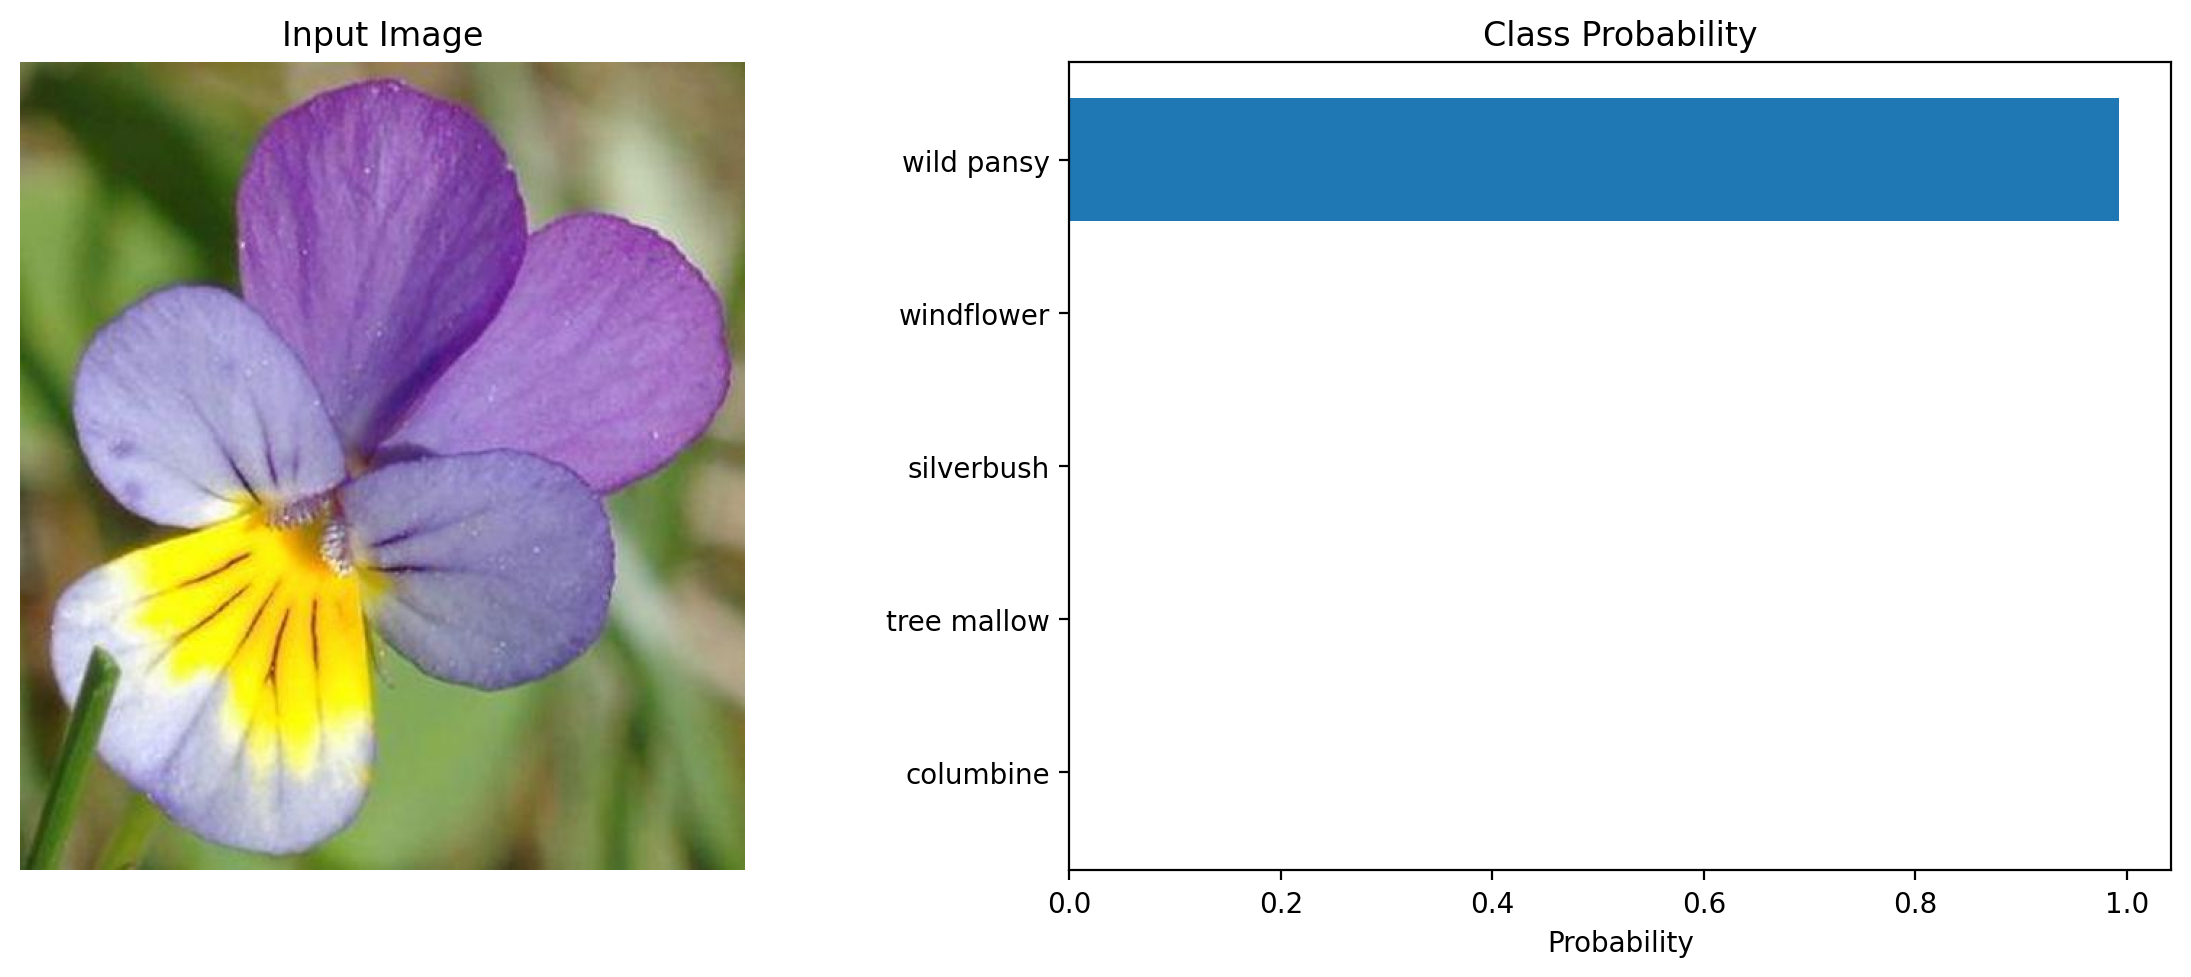

In [26]:
# TODO: Plot the input image along with the top 5 classes
image_path = '/kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/wild_pansy.jpg'

probs, classes = predict(image_path, model, 5)

# Get flower names from class numbers
flower_names = [class_names[c] for c in classes]

# Load original image for display
from PIL import Image
im = Image.open(image_path)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(im)
ax1.axis('off')
ax1.set_title('Input Image')

ax2.barh(flower_names, probs)
ax2.set_xlabel('Probability')
ax2.set_title('Class Probability')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [27]:
%%writefile predict.py
import argparse
import json
import numpy as np
import tensorflow as tf
from PIL import Image


def process_image(image):
    """Resize and normalize image to (224, 224, 3) NumPy array"""
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    image = tf.image.resize(image, (224, 224))
    image /= 255.0
    return image.numpy()


def predict(image_path, model, top_k):
    """Return top K probabilities and classes for a given image"""
    im = Image.open(image_path)
    test_image = np.asarray(im)
    processed_image = process_image(test_image)
    expanded_image = np.expand_dims(processed_image, axis=0)
    predictions = model.predict(expanded_image)
    top_k_probs, top_k_indices = tf.math.top_k(predictions[0], k=top_k)
    top_k_probs = top_k_probs.numpy().tolist()
    top_k_classes = [str(idx) for idx in top_k_indices.numpy().tolist()]
    return top_k_probs, top_k_classes


# Argument parser
parser = argparse.ArgumentParser(description='Flower Species Classifier')
parser.add_argument('image_path', type=str, help='Path to input image')
parser.add_argument('saved_model', type=str, help='Path to saved Keras model (.h5 or .keras)')
parser.add_argument('--top_k', type=int, default=1, help='Return top K most likely classes')
parser.add_argument('--category_names', type=str, default=None, help='Path to JSON file mapping labels to flower names')
args = parser.parse_args()

# Load model
model = tf.keras.models.load_model(args.saved_model)

# Predict
probs, classes = predict(args.image_path, model, args.top_k)

# Load category names if provided
if args.category_names:
    with open(args.category_names, 'r') as f:
        class_names = json.load(f)
    classes = [class_names[c] for c in classes]

# Print results
print(f"\nTop {args.top_k} Predictions:")
print("-" * 30)
for prob, cls in zip(probs, classes):
    print(f"Class: {cls:<30} Probability: {prob:.4f}")

Writing predict.py


**Basic Usage:**

In [28]:
!python predict.py /kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/wild_pansy.jpg my_model.keras

2026-03-13 15:27:49.116266: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773415669.145338     881 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773415669.154983     881 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773415669.177148     881 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773415669.177204     881 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773415669.177209     881 computation_placer.cc:177] computation placer alr

**Top K:**

In [29]:
!python predict.py /kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/wild_pansy.jpg my_model.keras --top_k 3

2026-03-13 15:28:09.567951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773415689.594947     962 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773415689.602798     962 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773415689.622963     962 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773415689.623018     962 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773415689.623022     962 computation_placer.cc:177] computation placer alr

**With category names:**

In [30]:
!python predict.py /kaggle/input/datasets/nabeelsawafta/my-test-images/test_images/wild_pansy.jpg my_model.keras --top_k 5 --category_names /kaggle/input/datasets/nabeelsawafta/myjson/label_map.json

2026-03-13 15:28:29.433426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773415709.459604    1043 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773415709.467258    1043 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773415709.487759    1043 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773415709.487811    1043 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773415709.487816    1043 computation_placer.cc:177] computation placer alr

In [31]:
import os
print(os.listdir('/kaggle/working/'))

['predict.py', '.virtual_documents', 'my_model.keras']
